In [ ]:
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms
from model import BEVModel
import torch.nn as nn
import torch.nn.functional as F
nusc=NuScenes(version='v1.0-mini',dataroot='D:\Python\ML Projects\BEV',verbose='True')
scene=nusc.scene[0]
print(scene)
sample_token=scene['first_sample_token']
samples=[]
for i in range(50):
    sample=nusc.get('sample',sample_token)
    samples.append(sample)
    if sample['next']=="":
        break
    sample_token=sample['next']
model=BEVModel()
optimizer=torch.optim.Adam(model.parameters(),lr=0.0003)
loss_fn=nn.BCEWithLogitsLoss()
transform=transforms.Compose([transforms.ToPILImage(),transforms.Resize((224,224)),transforms.ToTensor(),transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )])
def compute_iou(pred,target): #iou-intersection over union
    pred=(pred>0.02).float()
    target=(target>0.5).float()
    intersection=(pred*target).sum()
    union=pred.sum()+target.sum()-intersection
    return (intersection/union).item()
for epoch in range(15):
    total_loss=0
    total_iou=0.0
    for i,sample in enumerate(samples):
        cam_token=sample['data']['CAM_FRONT'] #getting camera image
        cam_data=nusc.get('sample_data',cam_token)
#loading and showing image
        img_path=os.path.join(nusc.dataroot,cam_data['filename'])
        img=cv2.imread(img_path)
        img_tensor=transform(img).unsqueeze(0)
        pts_src=np.float32([[500,300],[1100,300],[200,700],[1400,700]])
        pts_dst=np.float32([[0,0],[400,0],[0,600],[400,600]])
        H=cv2.getPerspectiveTransform(pts_src,pts_dst)
        bev_img=cv2.warpPerspective(img,H,(400,600))
        if epoch==0 and i==0:
            cv2.imshow("BEV IMAGE",bev_img)
            cv2.waitKey(1)
            cv2.destroyAllWindows()
        #loading lidar
        lidar_token=sample['data']['LIDAR_TOP']
        lidar_data=nusc.get('sample_data',lidar_token)
        lidar_path=os.path.join(nusc.dataroot,lidar_data['filename'])
        pc=LidarPointCloud.from_file(lidar_path)
        points=pc.points
        if epoch==0 and i==0:
            print(points.shape)
            x=points[0,:]
            y=points[1,:]
            plt.scatter(x,y,s=1)
            plt.title("LiDAR top view")
            plt.axis('equal')
            plt.show()
        mask=(points[0,:]>0) & (points[0,:]<50) & (points[1,:]>-25) & (points[1,:]<25)
        x=points[0,mask]
        y=points[1,mask]
        #converting to grid
        x_img=(x*10).astype(np.int32)
        y_img=(y*10).astype(np.int32)
        bev=np.zeros((500,500))
        bev = cv2.dilate(bev, np.ones((5,5), np.uint8))
        for j in range(len(x_img)):
            if 0 <= x_img[j] < 500 and 0 <= y_img[j]+250 < 500:
                bev[x_img[j], y_img[j]+250] =1
        bev = cv2.dilate(bev, np.ones((5,5), np.uint8))
        if epoch==0 and i==0:
            plt.imshow(bev)
            plt.title("BEV GRID")
            plt.show()
        target_bev=torch.tensor(bev,dtype=torch.float32)
        target_bev=target_bev.unsqueeze(0).unsqueeze(0)
        target_bev=F.interpolate(target_bev,size=(56,56))
        pred=model(img_tensor)
        pred = F.interpolate(pred, size=(56,56), mode='bilinear', align_corners=False)
        loss=loss_fn(pred,target_bev)
        occupied_weight = 0.5
        loss += occupied_weight * (target_bev * (pred - target_bev)**2).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        output = model(img_tensor)
        output = F.interpolate(output, size=(56,56))
        pred = torch.sigmoid(output).detach().numpy()[0,0]
        total_loss+=loss.item()
        total_iou += compute_iou(output, target_bev)

    print(f"Epoch {epoch} Loss: {total_loss}")
print("Average IoU:", total_iou / len(samples))
output=model(img_tensor)
output= F.interpolate(output, size=(56,56), mode='bilinear', align_corners=False)
print("OUTPUT SHAPE:",output.shape)
print("LOSS:",loss.item())
pred=output.detach().numpy()[0,0]
plt.imshow(pred)
plt.title("PREDICTED BEV")
plt.show()
sample = samples[-1]

cam_token = sample['data']['CAM_FRONT']
cam_data = nusc.get('sample_data', cam_token)
img_path = os.path.join(nusc.dataroot, cam_data['filename'])
img = cv2.imread(img_path)
img_tensor = transform(img).unsqueeze(0)
# recompute LiDAR BEV for last sample
lidar_token = sample['data']['LIDAR_TOP']
lidar_data = nusc.get('sample_data', lidar_token)
lidar_path = os.path.join(nusc.dataroot, lidar_data['filename'])

pc = LidarPointCloud.from_file(lidar_path)
points = pc.points

mask = (points[0,:]>0) & (points[0,:]<50) & (points[1,:]>-25) & (points[1,:]<25)

x = points[0,mask]
y = points[1,mask]

x_img = (x*10).astype(np.int32)
y_img = (y*10).astype(np.int32)

bev = np.zeros((500,500))

for j in range(len(x_img)):
    if 0 <= x_img[j] < 500 and 0 <= y_img[j]+250 < 500:
        bev[x_img[j], y_img[j]+250] = 1

target_bev = torch.tensor(bev, dtype=torch.float32)
target_bev = target_bev.unsqueeze(0).unsqueeze(0)
target_bev = F.interpolate(target_bev, size=(56,56))
target_bev = target_bev.clamp(0,1)
output = model(img_tensor)
output = F.interpolate(output, size=(56,56))
pred = torch.sigmoid(output).detach().numpy()[0,0]
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(bev_img)
plt.title("Homography")
plt.subplot(1,3,2)
plt.imshow(pred)
plt.title("Model Prediction")
plt.subplot(1,3,3)
plt.imshow(target_bev[0,0].numpy())
plt.title("LiDAR Ground Truth")
plt.show()
plt.imshow(pred)
plt.title("Predicted BEV")
plt.show()
output=torch.sigmoid(output)
print("IoU:",compute_iou(output,target_bev))
print("Pred max:", pred.max().item())
torch.save(model.state_dict(),"bev_model.pth")
model.load_state_dict(torch.load("bev_model.pth"))
model.eval()

In [ ]:
import cv2
import numpy as np
import os


CAMERAS = {
    "FRONT"        : {"file": "my_images/front.jpeg",       "angle_deg":   0},
    "FRONT_RIGHT"  : {"file": "my_images/front_right.jpeg", "angle_deg":  60},
    "BACK_RIGHT"   : {"file": "my_images/back_right.jpeg",  "angle_deg": 120},
    "BACK"         : {"file": "my_images/back.jpeg",        "angle_deg": 180},
    "BACK_LEFT"    : {"file": "my_images/back_left.jpeg",   "angle_deg": 240},
    "FRONT_LEFT"   : {"file": "my_images/front_left.jpeg",  "angle_deg": 300},
}

# ── BEV canvas: metres visible in each direction from vehicle centre ────────
BEV_RANGE  = 30.0   # metres (half-width and half-height)
BEV_RES    = 0.05   # metres per pixel
BEV_SIZE   = int(2 * BEV_RANGE / BEV_RES)   # 1200 × 1200 px

print(f"BEV canvas: {BEV_SIZE} × {BEV_SIZE} px  ({2*BEV_RANGE}m × {2*BEV_RANGE}m)")

# Check which files exist
for name, info in CAMERAS.items():
    ok = "exists" if os.path.exists(info["file"]) else " missing"
    print(f"  {ok}  {name:15s}  {info['file']}")

BEV canvas: 1200 × 1200 px  (60.0m × 60.0m)
  ✅  FRONT            my_images/front.jpeg
  ✅  FRONT_RIGHT      my_images/front_right.jpeg
  ✅  BACK_RIGHT       my_images/back_right.jpeg
  ✅  BACK             my_images/back.jpeg
  ✅  BACK_LEFT        my_images/back_left.jpeg
  ✅  FRONT_LEFT       my_images/front_left.jpeg


In [ ]:

def get_src_points(img_w, img_h, cam_name):
    """
    Returns (4,2) float32 trapezoid corners for the given camera.
    Adjust fractions per camera if their FOV / mounting differs.
    """
    presets = {
        # (top-left, top-right, bottom-right, bottom-left)  as (fx, fy)
        "FRONT"       : [(0.35,0.55),(0.65,0.55),(0.90,0.95),(0.10,0.95)],
        "BACK"        : [(0.35,0.55),(0.65,0.55),(0.90,0.95),(0.10,0.95)],
        "FRONT_RIGHT" : [(0.30,0.52),(0.70,0.52),(0.95,0.96),(0.05,0.96)],
        "FRONT_LEFT"  : [(0.30,0.52),(0.70,0.52),(0.95,0.96),(0.05,0.96)],
        "BACK_RIGHT"  : [(0.30,0.52),(0.70,0.52),(0.95,0.96),(0.05,0.96)],
        "BACK_LEFT"   : [(0.30,0.52),(0.70,0.52),(0.95,0.96),(0.05,0.96)],
    }
    fracs = presets.get(cam_name, [(0.35,0.55),(0.65,0.55),(0.90,0.95),(0.10,0.95)])
    return np.float32([[fx * img_w, fy * img_h] for fx, fy in fracs])

In [ ]:
from bev_transform import build_homography, warp_to_bev

def make_dst_points(bev_size, sector_deg, fov_deg=60):
    """
    Maps the road trapezoid into a sector of the BEV canvas.
    The sector is centred on `sector_deg` (0 = forward/up on canvas).
    """
    cx, cy = bev_size // 2, bev_size // 2
    r_far  = bev_size // 2              # far edge  (horizon)
    r_near = bev_size // 8              # near edge (bonnet / rear bumper)
    hw     = int(np.tan(np.radians(fov_deg / 2)) * r_far * 0.6)

    # Centre sector: top of canvas = forward
    # Rotate destination points by sector_deg
    def rot(x, y, deg):
        rad = np.radians(deg)
        x2  = x * np.cos(rad) - y * np.sin(rad)
        y2  = x * np.sin(rad) + y * np.cos(rad)
        return cx + x2, cy + y2

    tl = rot(-hw, -r_far,  sector_deg)
    tr = rot( hw, -r_far,  sector_deg)
    br = rot( hw, -r_near, sector_deg)
    bl = rot(-hw, -r_near, sector_deg)

    return np.float32([tl, tr, br, bl])


def warp_camera_to_bev(img_bgr, cam_name, bev_size):
    h, w = img_bgr.shape[:2]
    angle = CAMERAS[cam_name]["angle_deg"]

    src = get_src_points(w, h, cam_name)
    dst = make_dst_points(bev_size, sector_deg=angle)

    H   = build_homography(src, dst)
    bev = warp_to_bev(img_bgr, H, bev_size=(bev_size, bev_size))
    return bev, H

In [ ]:
def feather_mask(bev_warp: np.ndarray, feather_px: int = 60) -> np.ndarray:
    """
    Creates a soft alpha mask: bright where the warp has content,
    feathered at the edges so cameras blend smoothly.
    """
    gray  = cv2.cvtColor(bev_warp, cv2.COLOR_BGR2GRAY)
    mask  = (gray > 5).astype(np.float32)              # 1 where content exists

    # Distance transform gives smooth gradient from edge inward
    dist  = cv2.distanceTransform(
                mask.astype(np.uint8), cv2.DIST_L2, 5)
    dist  = np.clip(dist / feather_px, 0, 1)
    return dist[:, :, np.newaxis]                       # (H, W, 1)


def stitch_bev_views(bev_size: int, feather_px: int = 60) -> np.ndarray:
    canvas      = np.zeros((bev_size, bev_size, 3), dtype=np.float32)
    weight_sum  = np.zeros((bev_size, bev_size, 1), dtype=np.float32)

    for cam_name, info in CAMERAS.items():
        path = info["file"]
        if not os.path.exists(path):
            print(f"  ⚠️  Skipping {cam_name} — file not found")
            continue

        img  = cv2.imread(path)
        if img is None:
            print(f"  ⚠️  Could not read {path}")
            continue

        print(f"  Warping {cam_name} …", end=" ")
        bev_warp, _ = warp_camera_to_bev(img, cam_name, bev_size)
        alpha       = feather_mask(bev_warp, feather_px)

        canvas     += bev_warp.astype(np.float32) * alpha
        weight_sum += alpha
        print("done")

    # Normalise (avoid div-by-zero in areas no camera covers)
    weight_sum = np.where(weight_sum == 0, 1, weight_sum)
    stitched   = np.clip(canvas / weight_sum, 0, 255).astype(np.uint8)
    return stitched


print("Stitching cameras …")
bev_360 = stitch_bev_views(BEV_SIZE, feather_px=80)
print("Done.")

Stitching cameras …
  Warping FRONT … done
  Warping FRONT_RIGHT … done
  Warping BACK_RIGHT … done
  Warping BACK … done
  Warping BACK_LEFT … done
  Warping FRONT_LEFT … done
Done.


In [ ]:
def draw_overlay(bev: np.ndarray, bev_size: int) -> np.ndarray:
    out  = bev.copy()
    cx, cy = bev_size // 2, bev_size // 2

    # Vehicle rectangle (to scale at 0.05 m/px: car ~4.5m×2m = 90×40px)
    car_l, car_w = 90, 40
    cv2.rectangle(out,
                  (cx - car_w//2, cy - car_l//2),
                  (cx + car_w//2, cy + car_l//2),
                  (255, 255, 255), -1)
    cv2.rectangle(out,
                  (cx - car_w//2, cy - car_l//2),
                  (cx + car_w//2, cy + car_l//2),
                  (80, 80, 80), 2)

    # Direction arrow (forward = up on canvas)
    cv2.arrowedLine(out, (cx, cy + 20), (cx, cy - car_l//2 - 20),
                    (0, 220, 0), 3, tipLength=0.3)

    # Range rings (every 10 m)
    px_per_m = int(1.0 / 0.05)
    for r_m in [10, 20, 30]:
        r_px = r_m * px_per_m
        cv2.circle(out, (cx, cy), r_px, (180, 180, 180), 1, cv2.LINE_AA)
        cv2.putText(out, f"{r_m}m", (cx + r_px + 4, cy - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (220, 220, 220), 1)

    # Compass labels
    for label, (ox, oy) in [("N",(0,-1)),("S",(0,1)),("E",(1,0)),("W",(-1,0))]:
        tx = cx + ox * (BEV_SIZE//2 - 30)
        ty = cy + oy * (BEV_SIZE//2 - 30)
        cv2.putText(out, label, (tx - 8, ty + 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 220, 60), 2)

    return out


bev_annotated = draw_overlay(bev_360, BEV_SIZE)

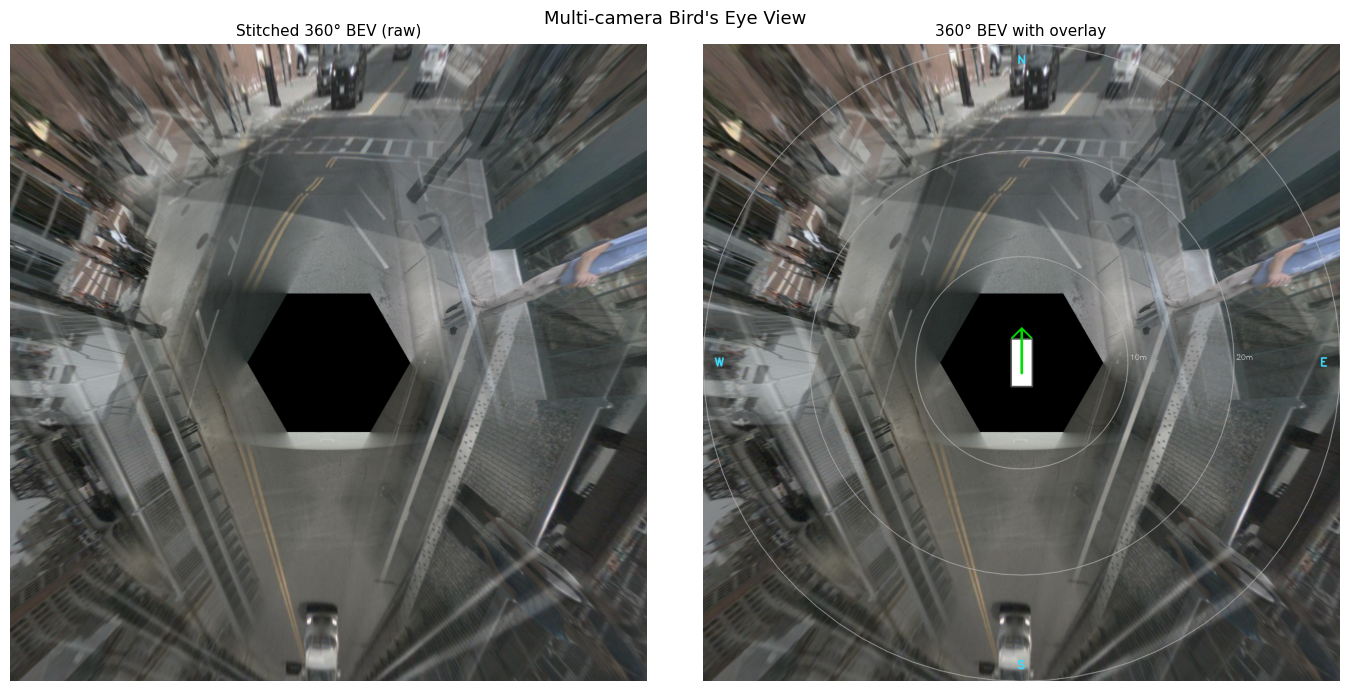

Saved → my_images/bev_360.jpg


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(cv2.cvtColor(bev_360,       cv2.COLOR_BGR2RGB))
axes[0].set_title("Stitched 360° BEV (raw)", fontsize=11)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(bev_annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title("360° BEV with overlay", fontsize=11)
axes[1].axis("off")

plt.suptitle("Multi-camera Bird's Eye View", fontsize=13)
plt.tight_layout()
plt.show()

cv2.imwrite("my_images/bev_360.jpg", bev_annotated)
print("Saved → my_images/bev_360.jpg")

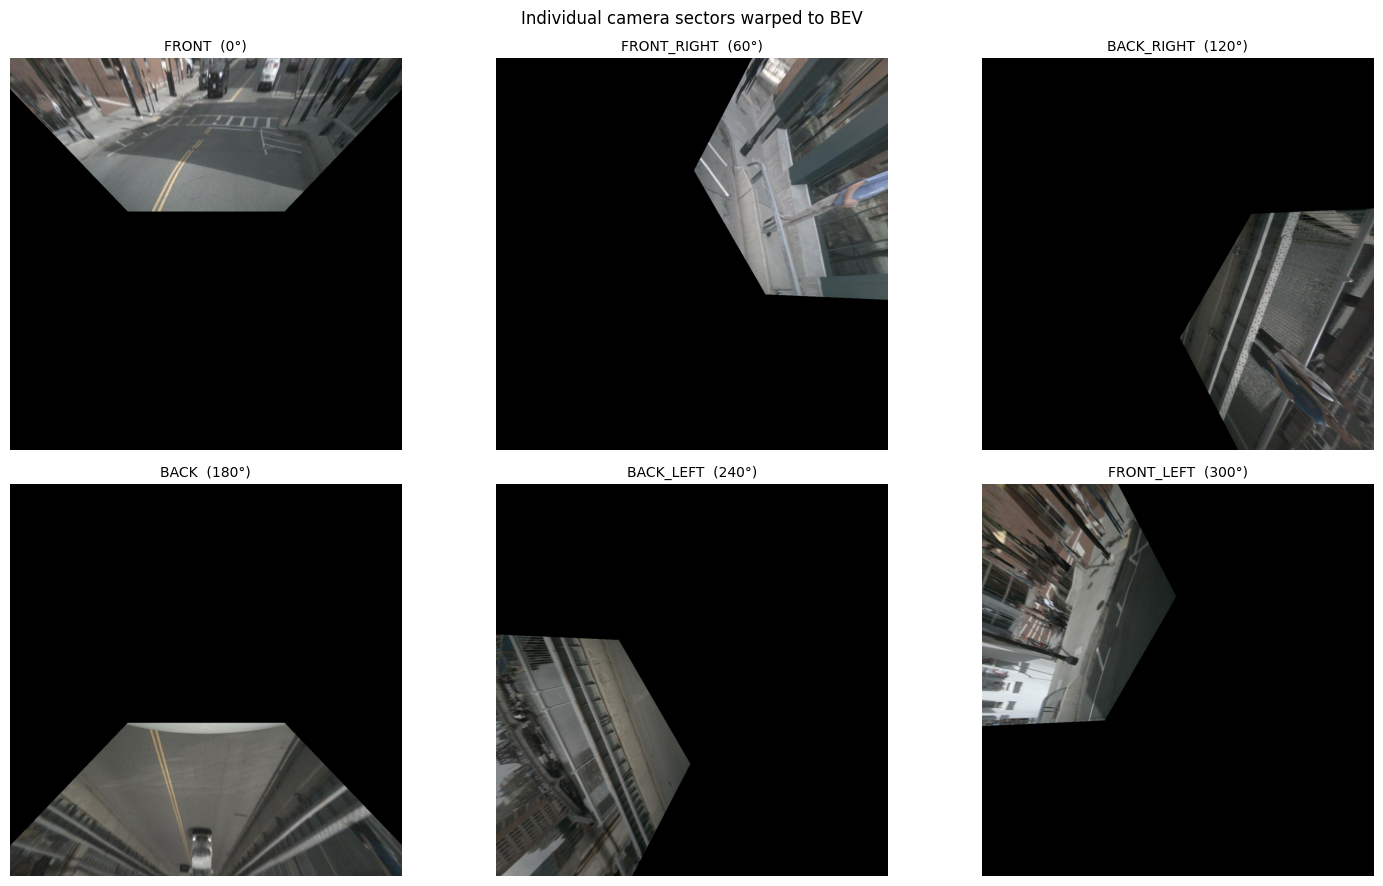

In [ ]:
n = len(CAMERAS)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (cam_name, info) in enumerate(CAMERAS.items()):
    path = info["file"]
    if not os.path.exists(path):
        axes[i].set_title(f"{cam_name} — missing"); axes[i].axis("off"); continue

    img      = cv2.imread(path)
    bev_sec, _ = warp_camera_to_bev(img, cam_name, BEV_SIZE)
    axes[i].imshow(cv2.cvtColor(bev_sec, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"{cam_name}  ({info['angle_deg']}°)", fontsize=10)
    axes[i].axis("off")

plt.suptitle("Individual camera sectors warped to BEV", fontsize=12)
plt.tight_layout()
plt.show()